# Clade refresh rate against stem mutation load

For every clade with posterior support between 5% and 95%, count how often it appears or disappears between consecutive logged trees, divide by $2p(1-p)$ (the flip rate of an independent sampler) and convert to wall-clock minutes and, independently of the cost of a step, to millions of MCMC samples. Clades are grouped by the expected number of mutations on their stem (stem time × clock rate × alignment length), which is what a topology move has to carry along in the EMAT.

In [49]:
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
sns.set_style("darkgrid")

# the run outputs live in the tests directory at the repository root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tests" / "hcv_emat.xml").exists())
TESTS_PATH = ROOT / "tests"

In [ ]:
# the wall-clock seconds per million MCMC samples of each run, which convert samples into running time
seconds_per_million_samples = {
    "hcv": {"emat": 12.0, "beauti": 23.0, "mix_3": 10.0},
    "zika": {"emat": 27.0, "beauti": 394.0},
    "sars": {"emat": 113.0, "beauti": 6300.0},
    "ebola": {"emat": 187.0, "mix": 723},
}

# the methods compared per experiment; runs without a tree file are skipped
method_names = {
    "hcv": ["emat", "beauti", "mix_3"],
    "zika": ["emat", "beauti"],
    "sars": ["emat", "beauti"],
    "ebola": ["emat", "mix"],
}

# flips are counted between consecutive trees, so a contiguous stretch is read after the burn-in
BURNIN_FRACTION = 0.1
MAX_NUM_TREES = 20000

# clock rates of runs that fix the clock instead of logging it
fixed_clock_rates = {"hcv": 7.9e-4}

SUPPORT_RANGE = (0.05, 0.95)
LOAD_BINS = [-np.inf, 0.5, 1.5, 3, 6, np.inf]
LOAD_LABELS = ["<0.5", "0.5–1.5", "1.5–3", "3–6", ">6"]

In [52]:
def read_contiguous_trees(path: Path, num_trees: int, start_fraction: float) -> list[str]:
    """Read up to num_trees consecutive tree lines, starting at the given fraction of the file size."""
    lines = []
    with open(path, "rb") as file:
        file.seek(int(path.stat().st_size * start_fraction))
        file.readline()

        for line in file:
            # a partially written last tree does not end with a semicolon
            if line.startswith(b"tree STATE_") and line.rstrip().endswith(b";"):
                lines.append(line.decode())
                if len(lines) >= num_trees:
                    break

    return lines


NEWICK_TOKEN = re.compile(r"\(|\)|,|:[^,();\[]+|\[[^\]]*\]|[^,():;\[]+")


def get_clade_stems(tree_line: str) -> dict[int, float]:
    """Map every non-root clade, as a bitmask over tip numbers, to the length of its stem branch."""
    newick = tree_line[tree_line.index("("):].strip().rstrip(";")

    stems = {}
    stack = []
    last_bits = None

    for token in NEWICK_TOKEN.findall(newick):
        if token == "(":
            stack.append(0)
        elif token == ")":
            last_bits = stack.pop()
            if stack:
                stack[-1] |= last_bits
        elif token == ",":
            last_bits = None
        elif token.startswith(":"):
            stems[last_bits] = float(token[1:])
        elif token.startswith("["):
            continue
        else:
            # tips are labelled by their number in the translate block
            last_bits = 1 << int(token)
            stack[-1] |= last_bits

    return stems

In [53]:
def get_mean_clock_rate(experiment: str) -> float:
    """Return the posterior mean clock rate from the EMAT log, or the fixed clock rate."""
    if experiment in fixed_clock_rates:
        return fixed_clock_rates[experiment]

    log_path = next(TESTS_PATH.glob(f"{experiment}_emat*.log"))
    log_df = pd.read_csv(log_path, comment="#", delimiter="\t")
    return log_df["clockRate"].values[len(log_df) // 10:].mean()


def get_alignment_length(experiment: str) -> int:
    """Return the alignment length of the experiment, read from the first sequence in its XML."""
    with open(TESTS_PATH / f"{experiment}_emat.xml") as file:
        for line in file:
            match = re.search(r'<sequence[^>]*value="([^"]+)"', line)
            if match:
                return len(match.group(1))

In [54]:
def get_uncertain_clades(experiment: str, method: str) -> pd.DataFrame:
    """Compute the refresh rate and stem mutation load of every uncertain clade of one run."""
    tree_paths = sorted(TESTS_PATH.glob(f"{experiment}_{method}-*.trees"))
    if not tree_paths:
        print(f"no trees found for {experiment}_{method}")
        return pd.DataFrame()

    lines = read_contiguous_trees(tree_paths[0], MAX_NUM_TREES, BURNIN_FRACTION)
    states = [int(re.match(r"tree STATE_(\d+)", line).group(1)) for line in lines]

    presence = defaultdict(lambda: np.zeros(len(lines), dtype=bool))
    stem_sums = defaultdict(float)
    for i, line in enumerate(lines):
        for clade, stem in get_clade_stems(line).items():
            presence[clade][i] = True
            stem_sums[clade] += stem

    num_samples = len(lines) * (states[1] - states[0])
    minutes = num_samples * seconds_per_million_samples[experiment][method] / 1e6 / 60
    mutations_per_time = get_mean_clock_rate(experiment) * get_alignment_length(experiment)

    rows = []
    for clade, present in presence.items():
        support = present.mean()
        if not SUPPORT_RANGE[0] < support < SUPPORT_RANGE[1]:
            continue

        flips = (present[1:] != present[:-1]).sum()
        rows.append({
            "experiment": experiment,
            "method": method,
            "support": support,
            "refreshes_per_minute": flips / minutes / (2 * support * (1 - support)),
            "refreshes_per_million_samples": flips / num_samples * 1e6 / (2 * support * (1 - support)),
            "stem_mutations": stem_sums[clade] / present.sum() * mutations_per_time,
        })

    print(f"{experiment}_{method}: {len(lines)} trees, {minutes:.1f} min, {len(rows)} uncertain clades")
    return pd.DataFrame(rows)

In [55]:
clades_df = pd.concat([
    get_uncertain_clades(experiment, method)
    for experiment, methods in method_names.items()
    for method in methods
])
clades_df["load_bin"] = pd.cut(clades_df["stem_mutations"], LOAD_BINS, labels=LOAD_LABELS)

hcv_emat: 20000 trees, 4.0 min, 143 uncertain clades
hcv_beauti: 20000 trees, 7.7 min, 129 uncertain clades
hcv_mix_3: 20000 trees, 3.3 min, 124 uncertain clades
zika_emat: 20000 trees, 9.0 min, 371 uncertain clades
zika_beauti: 10488 trees, 68.9 min, 444 uncertain clades
sars_emat: 240 trees, 0.5 min, 2590 uncertain clades
sars_beauti: 15 trees, 1.6 min, 4071 uncertain clades
ebola_emat: 20000 trees, 62.3 min, 3520 uncertain clades
ebola_mix: 20000 trees, 241.0 min, 3825 uncertain clades


In [56]:
# the median refresh rates and number of uncertain clades per stem load bin
summary_df = (
    clades_df.groupby(["experiment", "method", "load_bin"], observed=False)
    .agg(
        median_refreshes_per_minute=("refreshes_per_minute", "median"),
        median_refreshes_per_million_samples=("refreshes_per_million_samples", "median"),
        num_clades=("support", "size"),
    )
    .reset_index()
)
summary_df.pivot_table(index=["experiment", "load_bin"], columns="method", values=["median_refreshes_per_minute", "median_refreshes_per_million_samples", "num_clades"], observed=False).round(2)

median_refreshes_per_million_samples                 \
method                                            beauti    emat    mix   
experiment load_bin                                                       
ebola      <0.5                                      NaN   45.94  27.06   
           0.5–1.5                                   NaN   30.77   8.66   
           1.5–3                                     NaN    8.59   2.00   
           3–6                                       NaN     NaN    NaN   
           >6                                        NaN     NaN    NaN   
hcv        <0.5                                   881.61     NaN    NaN   
           0.5–1.5                                783.94  131.82    NaN   
           1.5–3                                  428.78   25.43    NaN   
           3–6                                    163.51   10.19    NaN   
           >6                                     725.06   11.03    NaN   
sars       <0.5                                   576.92   63.31    NaN   
           0.5–1.5                                535.71   54.55    NaN   
           1.5–3                                  576.92   40.43    NaN   
           3–6                                    576.92   21.57    NaN   
           >6                                    1071.43    9.82    NaN   
zika       <0.5                                   686.98  390.51    NaN   
           0.5–1.5                                566.41  318.27    NaN   
           1.5–3                                  255.09   74.24    NaN   
           3–6                                    165.07    9.41    NaN   
           >6                                       0.59    5.32    NaN   

                            median_refreshes_per_minute                        \
method                mix_3                      beauti    emat   mix   mix_3   
experiment load_bin                                                             
ebola      <0.5         NaN                         NaN   14.74  2.25     NaN   
           0.5–1.5      NaN                         NaN    9.87  0.72     NaN   
           1.5–3        NaN                         NaN    2.76  0.17     NaN   
           3–6          NaN                         NaN     NaN   NaN     NaN   
           >6           NaN                         NaN     NaN   NaN     NaN   
hcv        <0.5      101.64                     2299.86     NaN   NaN  609.86   
           0.5–1.5    91.69                     2045.06  659.08   NaN  550.15   
           1.5–3      61.98                     1118.56  127.16   NaN  371.86   
           3–6        17.26                      426.54   50.97   NaN  103.56   
           >6         27.20                     1891.45   55.15   NaN  163.23   
sars       <0.5         NaN                        5.49   33.61   NaN     NaN   
           0.5–1.5      NaN                        5.10   28.96   NaN     NaN   
           1.5–3        NaN                        5.49   21.47   NaN     NaN   
           3–6          NaN                        5.49   11.45   NaN     NaN   
           >6           NaN                       10.20    5.21   NaN     NaN   
zika       <0.5         NaN                      104.62  867.80   NaN     NaN   
           0.5–1.5      NaN                       86.26  707.28   NaN     NaN   
           1.5–3        NaN                       38.85  164.98   NaN     NaN   
           3–6          NaN                       25.14   20.92   NaN     NaN   
           >6           NaN                        0.09   11.83   NaN     NaN   

                    num_clades                        
method                  beauti    emat     mix mix_3  
experiment load_bin                                   
ebola      <0.5            NaN  2392.0  2635.0   NaN  
           0.5–1.5         NaN  1101.0  1148.0   NaN  
           1.5–3           NaN    27.0    42.0   NaN  
           3–6             NaN     0.0     0.0   NaN  
           >6              NaN     0.0     0.

In [57]:
# share of uncertain clades with more than 1.5 expected mutations on their stem
clades_df.groupby(["experiment", "method"])["stem_mutations"].apply(lambda loads: (loads > 1.5).mean()).round(3)

experiment  method
ebola       emat      0.008
            mix       0.011
hcv         beauti    0.574
            emat      0.573
            mix_3     0.556
sars        beauti    0.468
            emat      0.093
zika        beauti    0.270
            emat      0.210
Name: stem_mutations, dtype: float64

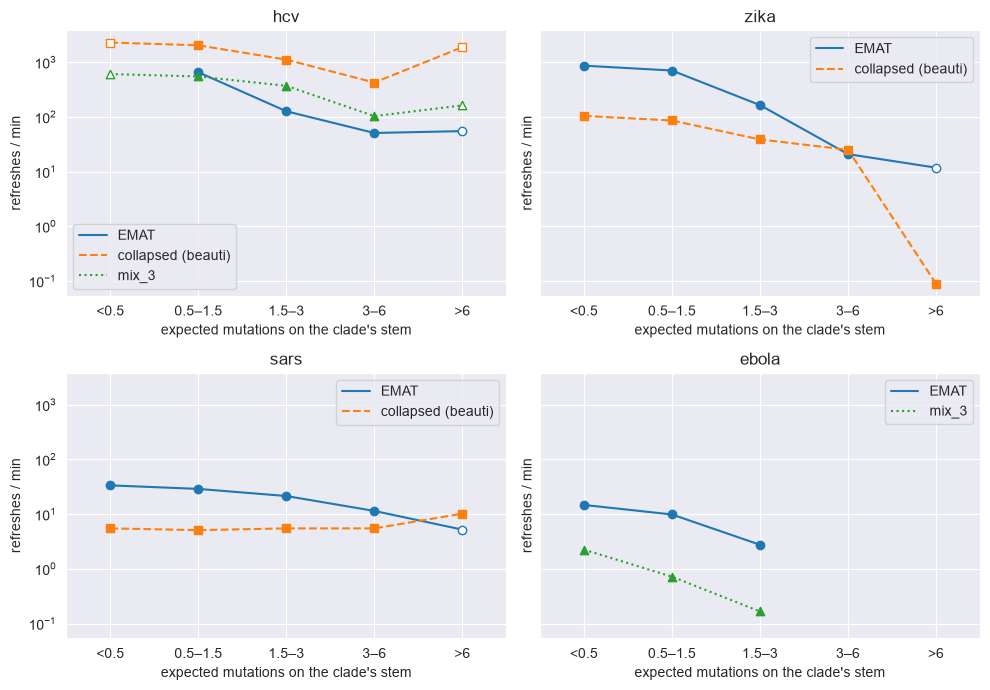

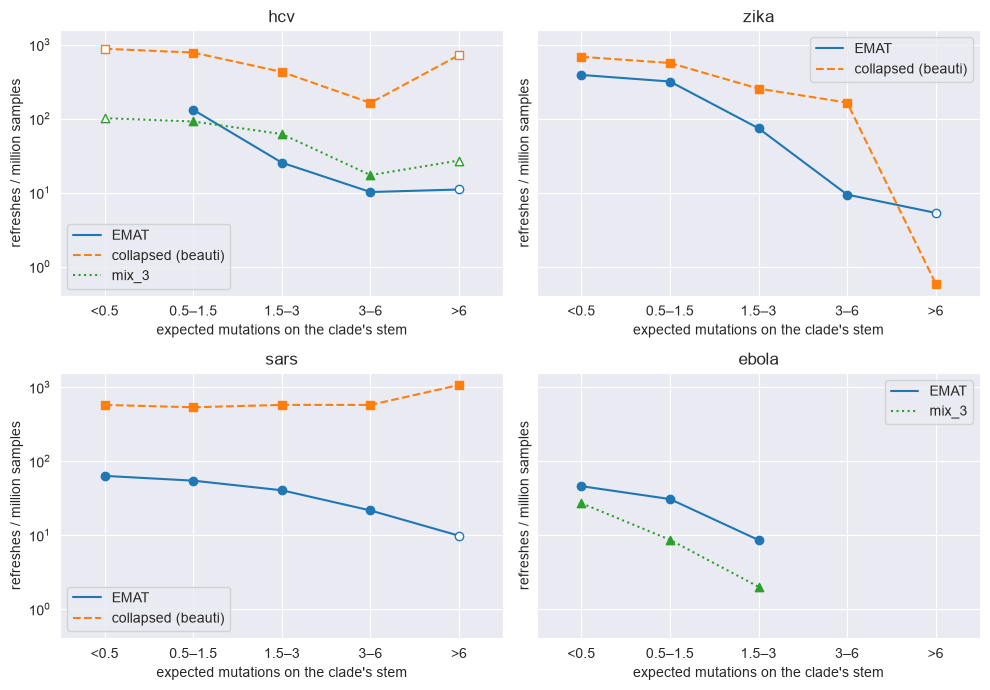

In [58]:
# bins with fewer than this many clades are drawn with hollow markers
MIN_CLADES = 5

method_styles = {
    "emat": {"color": "C0", "linestyle": "-", "marker": "o", "label": "EMAT"},
    "beauti": {"color": "C1", "linestyle": "--", "marker": "s", "label": "collapsed (beauti)"},
    "mix_3": {"color": "C2", "linestyle": ":", "marker": "^", "label": "mix_3"},
    "mix": {"color": "C2", "linestyle": ":", "marker": "^", "label": "mix_3"},
}


def plot_refresh_rates(value_column: str, ylabel: str):
    """Plot the median refresh rate per stem load bin for every experiment and method."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    for ax, experiment in zip(axes.flat, method_names):
        for method, style in method_styles.items():
            data = summary_df[(summary_df.experiment == experiment) & (summary_df.method == method)]
            data = data[data.num_clades > 0]
            if data.empty:
                continue

            x = data.load_bin.cat.codes.values
            y = data[value_column].values
            ax.plot(x, y, color=style["color"], linestyle=style["linestyle"], label=style["label"])

            is_small = data.num_clades.values < MIN_CLADES
            ax.scatter(x[~is_small], y[~is_small], color=style["color"], marker=style["marker"], zorder=3)
            ax.scatter(x[is_small], y[is_small], facecolor="white", edgecolor=style["color"], marker=style["marker"], zorder=3)

        ax.set_yscale("log")
        ax.set_xticks(range(len(LOAD_LABELS)), LOAD_LABELS)
        ax.set_xlim(-0.5, len(LOAD_LABELS) - 0.5)
        ax.set_title(experiment)
        ax.set_xlabel("expected mutations on the clade's stem")
        ax.set_ylabel(ylabel)
        ax.legend()

    fig.tight_layout()
    plt.show()


plot_refresh_rates("median_refreshes_per_minute", "refreshes / min")
plot_refresh_rates("median_refreshes_per_million_samples", "refreshes / million samples")